In [1]:
import pandas as pd
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.max_rows', None)      # Limit number of rows shown
pd.set_option('display.width', 1000)       # Width of the display in characters

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.stats as stats
import seaborn as sns

In [3]:
price = pd.read_csv('Ames_HousePrice.csv')
price.head(2)

,Unnamed: 0,PID,GrLivArea,SalePrice,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,909176150,856,126000,30,RL,NaN,7890,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Norm,Norm,1Fam,1Story,6,6,1939,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,238.0,Unf,0.0,618.0,856.0,GasA,TA,Y,SBrkr,856,0,0,1.0,0.0,1,0,2,1,TA,4,Typ,1,Gd,Detchd,1939.0,Unf,2.0,399.0,TA,TA,Y,0,0,0,0,166,0,NaN,NaN,NaN,0,3,2010,WD,Normal
1,2,905476230,1049,139500,120,RL,42.0,4235,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,TwnhsE,1Story,5,5,1984,1984,Gable,CompShg,HdBoard,HdBoard,BrkFace,149.0,Gd,TA,CBlock,Gd,TA,Mn,GLQ,552.0,ALQ,393.0,104.0,1049.0,GasA,TA,Y,SBrkr,1049,0,0,1.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1984.0,Fin,1.0,266.0,TA,TA,Y,0,105,0,0,0,0,NaN,NaN,NaN,0,2,2009,WD,Normal


In [4]:
price.shape

(2580, 82)

In [87]:
price.isnull().sum().head()

Unnamed: 0    0
PID           0
GrLivArea     0
SalePrice     0
MSSubClass    0
dtype: int64

In [6]:
price.isnull().sum().sum()

13813

In [85]:
price.dtypes.head()

Unnamed: 0    int64
PID           int64
GrLivArea     int64
SalePrice     int64
MSSubClass    int64
dtype: object

In [93]:
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 83 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     2580 non-null   int64  
 1   PID            2580 non-null   int64  
 2   GrLivArea      2580 non-null   int64  
 3   SalePrice      2580 non-null   int64  
 4   MSSubClass     2580 non-null   int64  
 5   MSZoning       2580 non-null   object 
 6   LotFrontage    2118 non-null   float64
 7   LotArea        2580 non-null   int64  
 8   Street         2580 non-null   object 
 9   Alley          168 non-null    object 
 10  LotShape       2580 non-null   object 
 11  LandContour    2580 non-null   object 
 12  Utilities      2580 non-null   object 
 13  LotConfig      2580 non-null   object 
 14  LandSlope      2580 non-null   object 
 15  Neighborhood   2580 non-null   object 
 16  Condition1     2580 non-null   object 
 17  Condition2     2580 non-null   object 
 18  BldgType

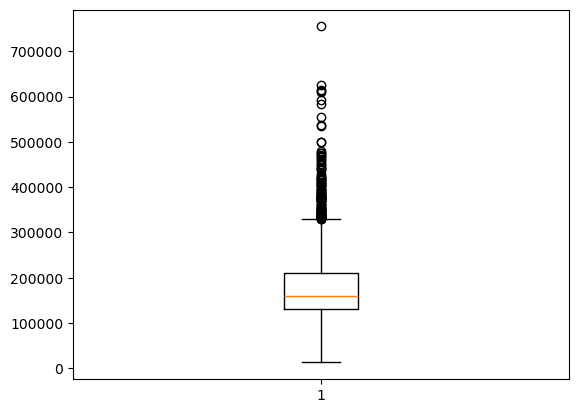

In [9]:
fig, ax = plt.subplots()

ax.boxplot(price['SalePrice'])

plt.show()

<BarContainer object of 5 artists>

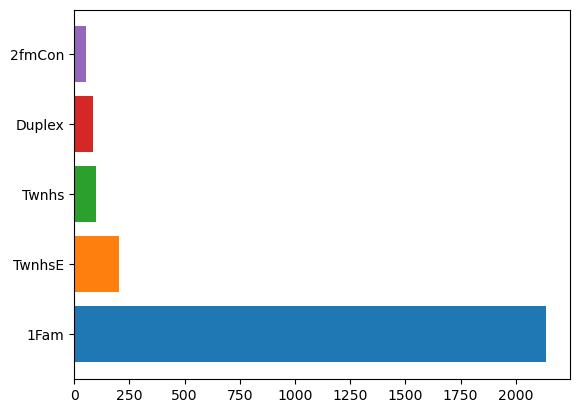

In [10]:
colors = sns.color_palette('tab10', n_colors=len(price['BldgType'].value_counts()))

plt.barh(y = price['BldgType'].value_counts().index, width = price['BldgType'].value_counts().values, color = colors)

In [11]:
price['HouseStyle'].value_counts()

HouseStyle
1Story    1288
2Story     773
1.5Fin     284
SLvl       118
SFoyer      70
2.5Unf      22
1.5Unf      19
2.5Fin       6
Name: count, dtype: int64

<BarContainer object of 8 artists>

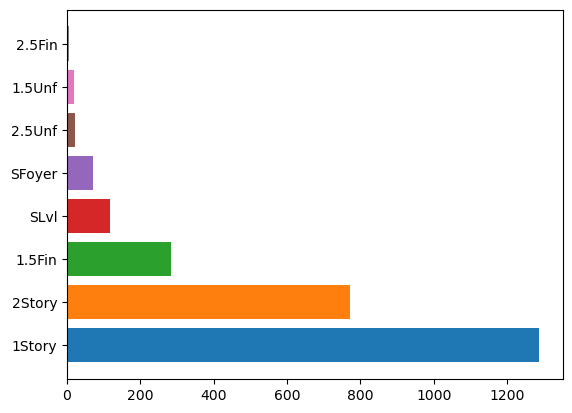

In [12]:
colors = sns.color_palette('tab10', n_colors=len(price['HouseStyle'].value_counts()))

plt.barh(y = price['HouseStyle'].value_counts().index, width = price['HouseStyle'].value_counts().values, color = colors)

In [83]:
columns_to_sum = [
    'PoolArea', 'EnclosedPorch', 'ScreenPorch', 'OpenPorchSF', 'WoodDeckSF',
    '3SsnPorch', 'GarageArea', 'GrLivArea', 'TotalBsmtSF', 'MasVnrArea'
]

# Make sure all NaNs are treated as 0 before summing
price['TotalArea'] = price[columns_to_sum].fillna(0).sum(axis=1)

price.head(2)

,Unnamed: 0,PID,GrLivArea,SalePrice,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalArea
0,1,909176150,856,126000,30,RL,NaN,7890,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Norm,Norm,1Fam,1Story,6,6,1939,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,238.0,Unf,0.0,618.0,856.0,GasA,TA,Y,SBrkr,856,0,0,1.0,0.0,1,0,2,1,TA,4,Typ,1,Gd,Detchd,1939.0,Unf,2.0,399.0,TA,TA,Y,0,0,0,0,166,0,NaN,NaN,NaN,0,3,2010,WD,Normal,2277.0
1,2,905476230,1049,139500,120,RL,42.0,4235,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,TwnhsE,1Story,5,5,1984,1984,Gable,CompShg,HdBoard,HdBoard,BrkFace,149.0,Gd,TA,CBlock,Gd,TA,Mn,GLQ,552.0,ALQ,393.0,104.0,1049.0,GasA,TA,Y,SBrkr,1049,0,0,1.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1984.0,Fin,1.0,266.0,TA,TA,Y,0,105,0,0,0,0,NaN,NaN,NaN,0,2,2009,WD,Normal,2618.0


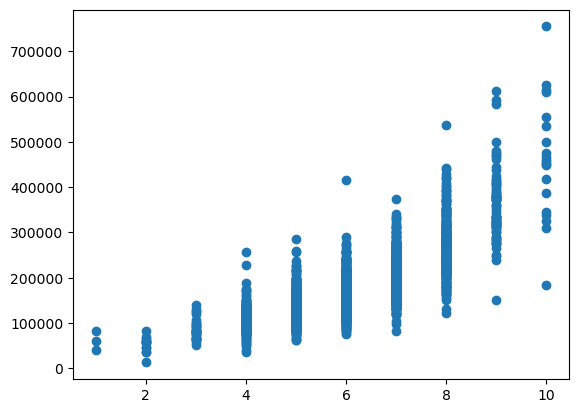

In [14]:
plt.scatter(x = price['OverallQual'], y = price['SalePrice'])

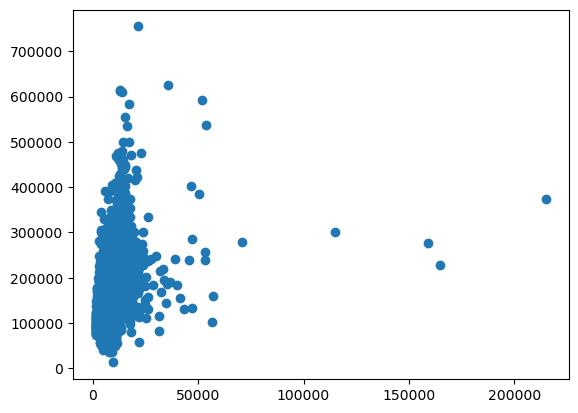

In [15]:
plt.scatter(x = price['LotArea'], y = price['SalePrice'])

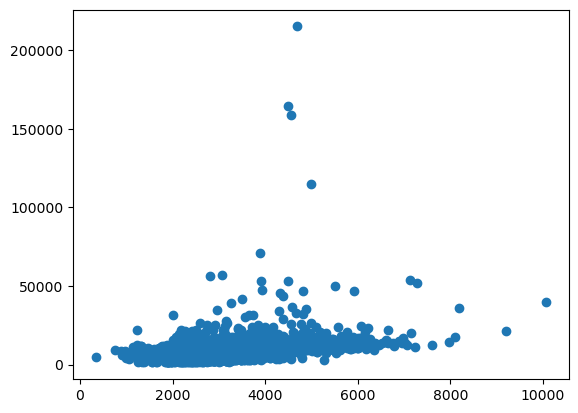

In [16]:
plt.scatter(x = price['TotalArea'], y = price['LotArea'])

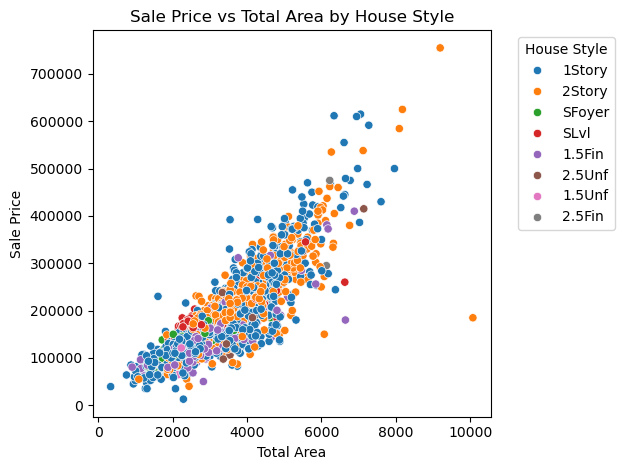

In [17]:
sns.scatterplot(
    data=price,
    x='TotalArea',
    y='SalePrice',
    hue='HouseStyle',
    palette='tab10'  # or try 'Set2', 'Dark2', etc.
)

plt.title('Sale Price vs Total Area by House Style')
plt.xlabel('Total Area')
plt.ylabel('Sale Price')
plt.legend(title='House Style', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/cl/t0tgh5md7pj6srx85p45398h0000gq/T/ipykernel_15446/289331479.py:27: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='TotalArea', y='SalePrice', data=data, palette = palette, ax=ax, alpha=0.5, color = palette[i])
/var/folders/cl/t0tgh5md7pj6srx85p45398h0000gq/T/ipykernel_15446/289331479.py:27: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='TotalArea', y='SalePrice', data=data, palette = palette, ax=ax, alpha=0.5, color = palette[i])
/var/folders/cl/t0tgh5md7pj6srx85p45398h0000gq/T/ipykernel_15446/289331479.py:27: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='TotalArea', y='SalePrice', data=data, palette = palette, ax=ax, alpha=0.5, color = palette[i])
/var/folders/cl/t0tgh5md7pj6srx85p45398h0000gq/T/ipykernel_15446/289331479.py:27: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplo

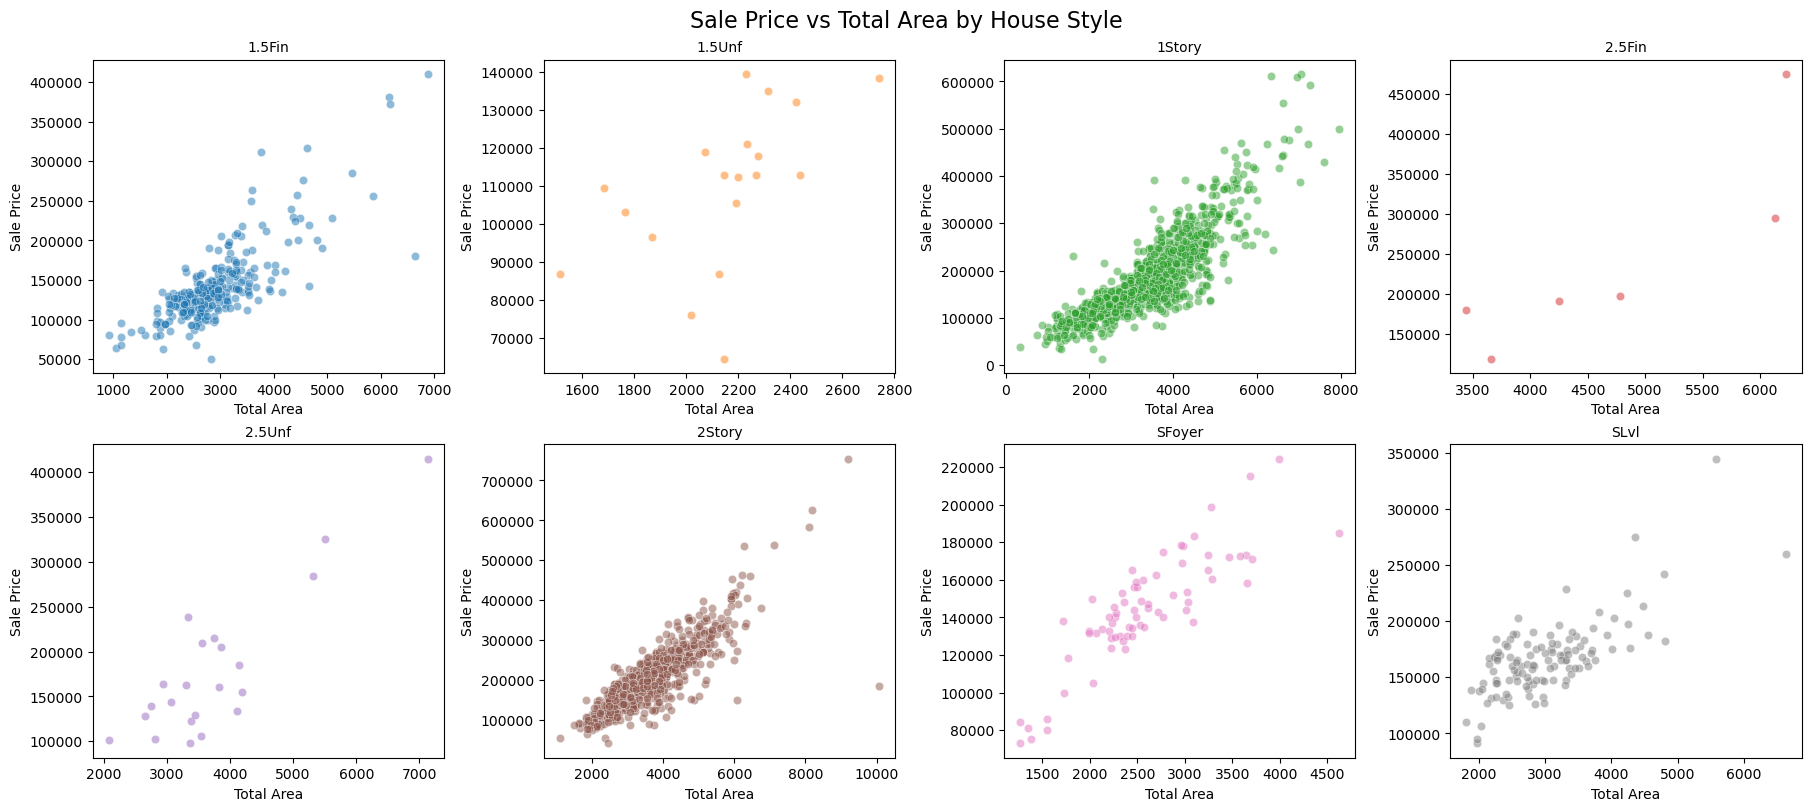

In [18]:
# Prepare data
df = price[['HouseStyle', 'TotalArea', 'SalePrice']].dropna()

# Get sorted list of neighborhoods
housestyles = sorted(df['HouseStyle'].unique())

# Plot layout
num_plots = len(housestyles)
num_cols = 4
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4), constrained_layout=True)
axes = axes.flatten()

palette = sns.color_palette("tab10", num_plots)

# Loop through neighborhoods
for i, housestyle in enumerate(housestyles):
    ax = axes[i]
    
    data = df[df['HouseStyle'] == housestyle]
    X = data[['TotalArea']]
    y = data['SalePrice']
    

    # Plot scatter and regression line
    sns.scatterplot(x='TotalArea', y='SalePrice', data=data, palette = palette, ax=ax, alpha=0.5, color = palette[i])
   
    
    # Set title 
    ax.set_title(f"{housestyle}", fontsize=10)
    ax.set_xlabel('Total Area')
    ax.set_ylabel('Sale Price')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Sale Price vs Total Area by House Style', fontsize=16)
plt.show()

/var/folders/cl/t0tgh5md7pj6srx85p45398h0000gq/T/ipykernel_15446/1009168268.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HouseStyle', y='SalePrice', data=df, palette = palette)


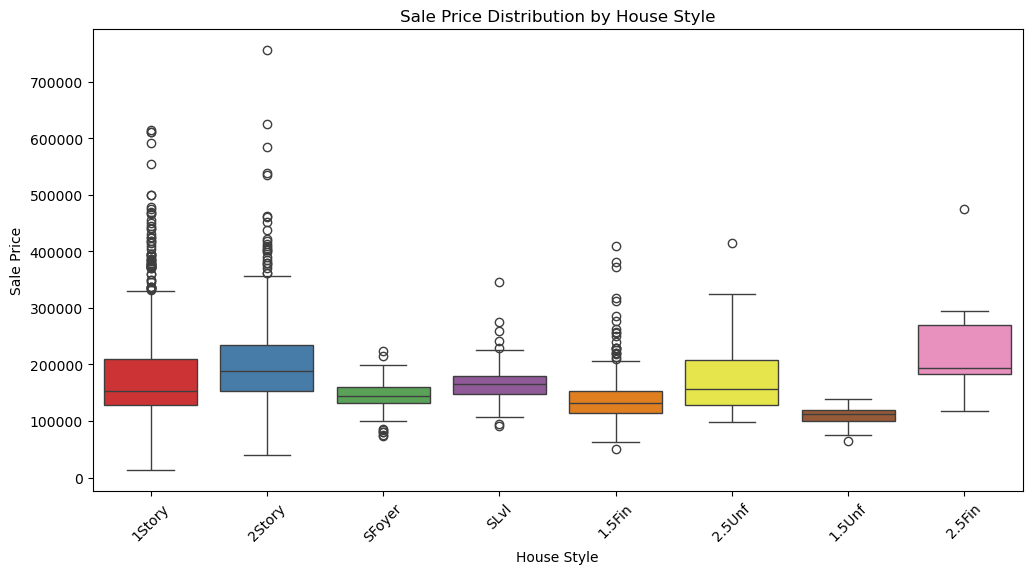

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
df = price[['HouseStyle', 'SalePrice']].dropna()

palette = sns.color_palette("Set1", len(df['HouseStyle'].unique()))

# Plot boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(x='HouseStyle', y='SalePrice', data=df, palette = palette)
plt.title('Sale Price Distribution by House Style')
plt.xlabel('House Style')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)  # Rotate x-labels if they overlap
plt.show()


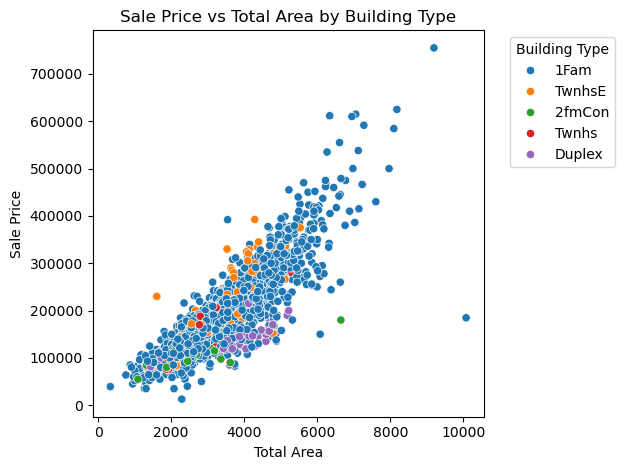

In [20]:
sns.scatterplot(
    data=price,
    x='TotalArea',
    y='SalePrice',
    hue='BldgType',
    palette='tab10'  # or try 'Set2', 'Dark2', etc.
)

plt.title('Sale Price vs Total Area by Building Type')
plt.xlabel('Total Area')
plt.ylabel('Sale Price')
plt.legend(title='Building Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

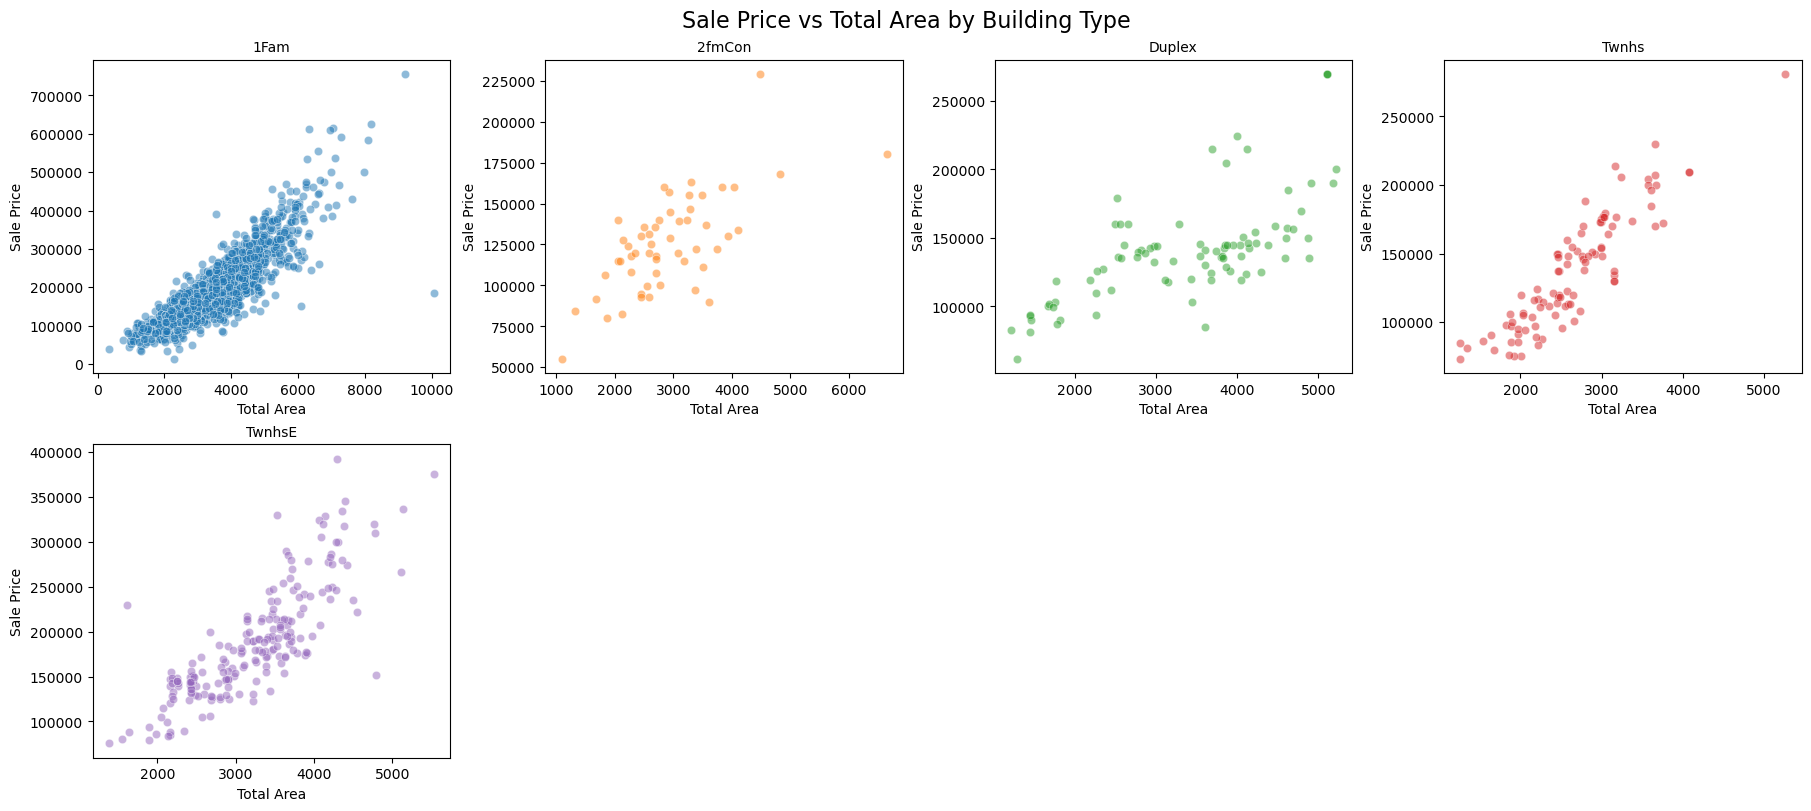

In [21]:
# Prepare data
df = price[['BldgType', 'TotalArea', 'SalePrice']].dropna()

# Get sorted list of neighborhoods
buildingtypes = sorted(df['BldgType'].unique())

# Plot layout
num_plots = len(buildingtypes)
num_cols = 4
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4), constrained_layout=True)
axes = axes.flatten()

palette = sns.color_palette("tab10", num_plots)

# Loop through neighborhoods
for i, buildingtype in enumerate(buildingtypes):
    ax = axes[i]
    
    data = df[df['BldgType'] == buildingtype]
    X = data[['TotalArea']]
    y = data['SalePrice']
    

    # Plot scatter and regression line
    sns.scatterplot(x='TotalArea', y='SalePrice', data=data, ax=ax, alpha=0.5, color = palette[i])
   
    
    # Set title 
    ax.set_title(f"{buildingtype}", fontsize=10)
    ax.set_xlabel('Total Area')
    ax.set_ylabel('Sale Price')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Sale Price vs Total Area by Building Type', fontsize=16)
plt.show()

/var/folders/cl/t0tgh5md7pj6srx85p45398h0000gq/T/ipykernel_15446/3976667507.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BldgType', y='SalePrice', data=df, palette = palette)


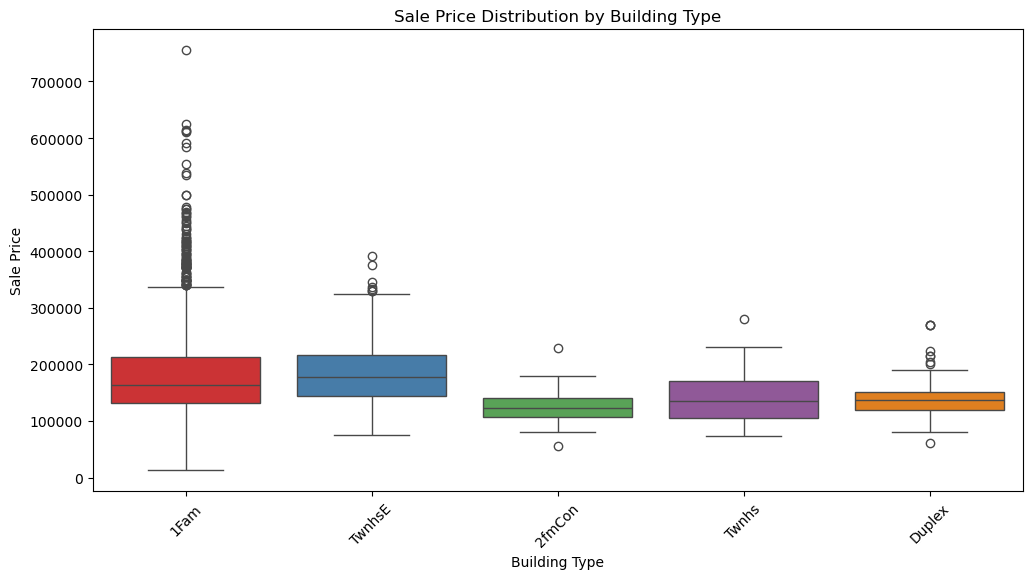

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
df = price[['BldgType', 'SalePrice']].dropna()

palette = sns.color_palette("Set1", len(df['BldgType'].unique()))

# Plot boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(x='BldgType', y='SalePrice', data=df, palette = palette)
plt.title('Sale Price Distribution by Building Type')
plt.xlabel('Building Type')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)  # Rotate x-labels if they overlap
plt.show()


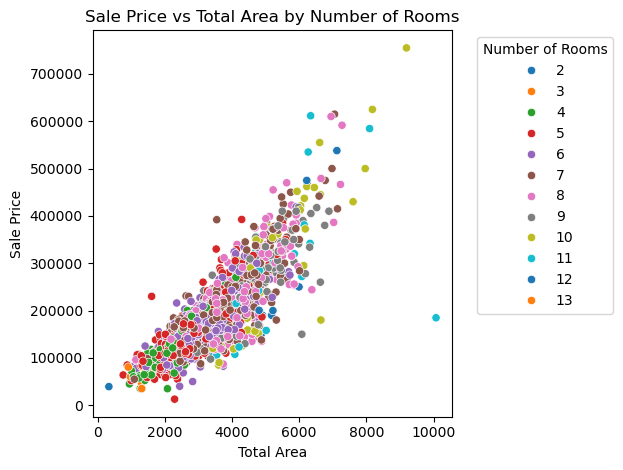

In [23]:
sns.scatterplot(
    data=price,
    x='TotalArea',
    y='SalePrice',
    hue='TotRmsAbvGrd',
    palette='tab10'  # or try 'Set2', 'Dark2', etc.
)

plt.title('Sale Price vs Total Area by Number of Rooms')
plt.xlabel('Total Area')
plt.ylabel('Sale Price')
plt.legend(title='Number of Rooms', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

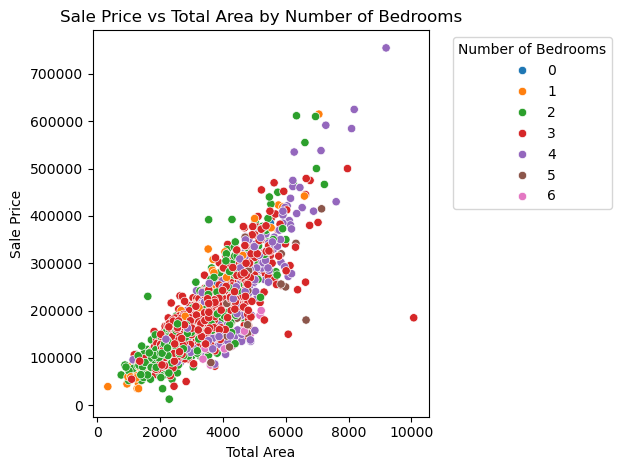

In [24]:
sns.scatterplot(
    data=price,
    x='TotalArea',
    y='SalePrice',
    hue='BedroomAbvGr',
    palette='tab10'  # or try 'Set2', 'Dark2', etc.
)

plt.title('Sale Price vs Total Area by Number of Bedrooms')
plt.xlabel('Total Area')
plt.ylabel('Sale Price')
plt.legend(title='Number of Bedrooms', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

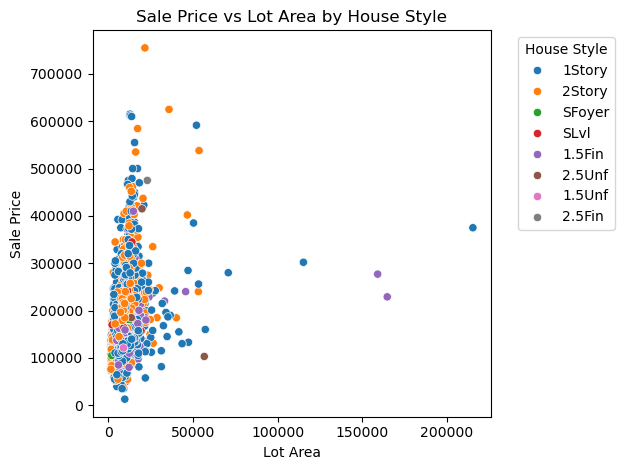

In [25]:
sns.scatterplot(
    data=price,
    x='LotArea',
    y='SalePrice',
    hue='HouseStyle',
    palette='tab10'  # or try 'Set2', 'Dark2', etc.
)

plt.title('Sale Price vs Lot Area by House Style')
plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.legend(title='House Style', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

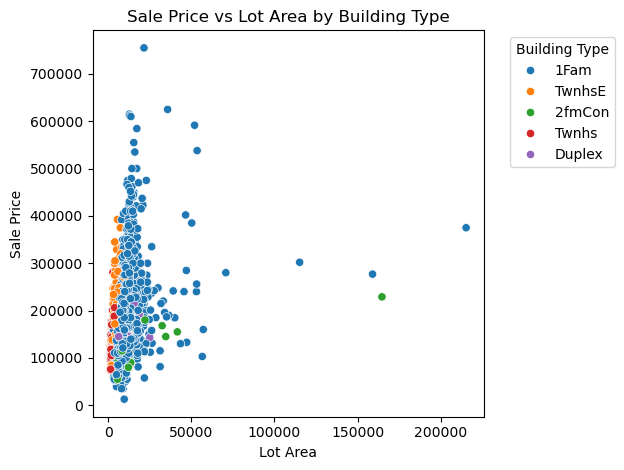

In [26]:
sns.scatterplot(
    data=price,
    x='LotArea',
    y='SalePrice',
    hue='BldgType',
    palette='tab10'  # or try 'Set2', 'Dark2', etc.
)

plt.title('Sale Price vs Lot Area by Building Type')
plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.legend(title='Building Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

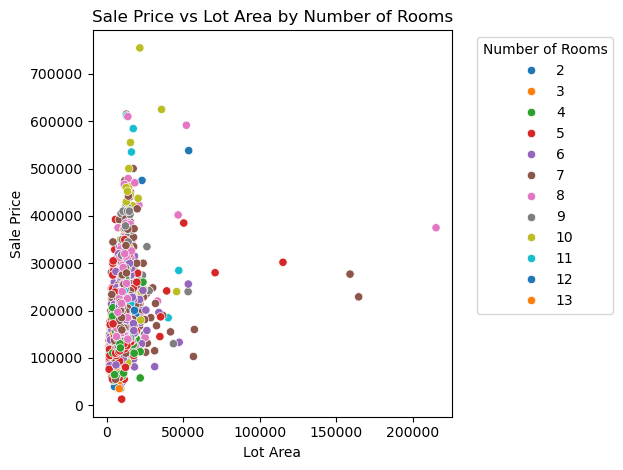

In [27]:
sns.scatterplot(
    data=price,
    x='LotArea',
    y='SalePrice',
    hue='TotRmsAbvGrd',
    palette='tab10'  # or try 'Set2', 'Dark2', etc.
)

plt.title('Sale Price vs Lot Area by Number of Rooms')
plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.legend(title='Number of Rooms', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

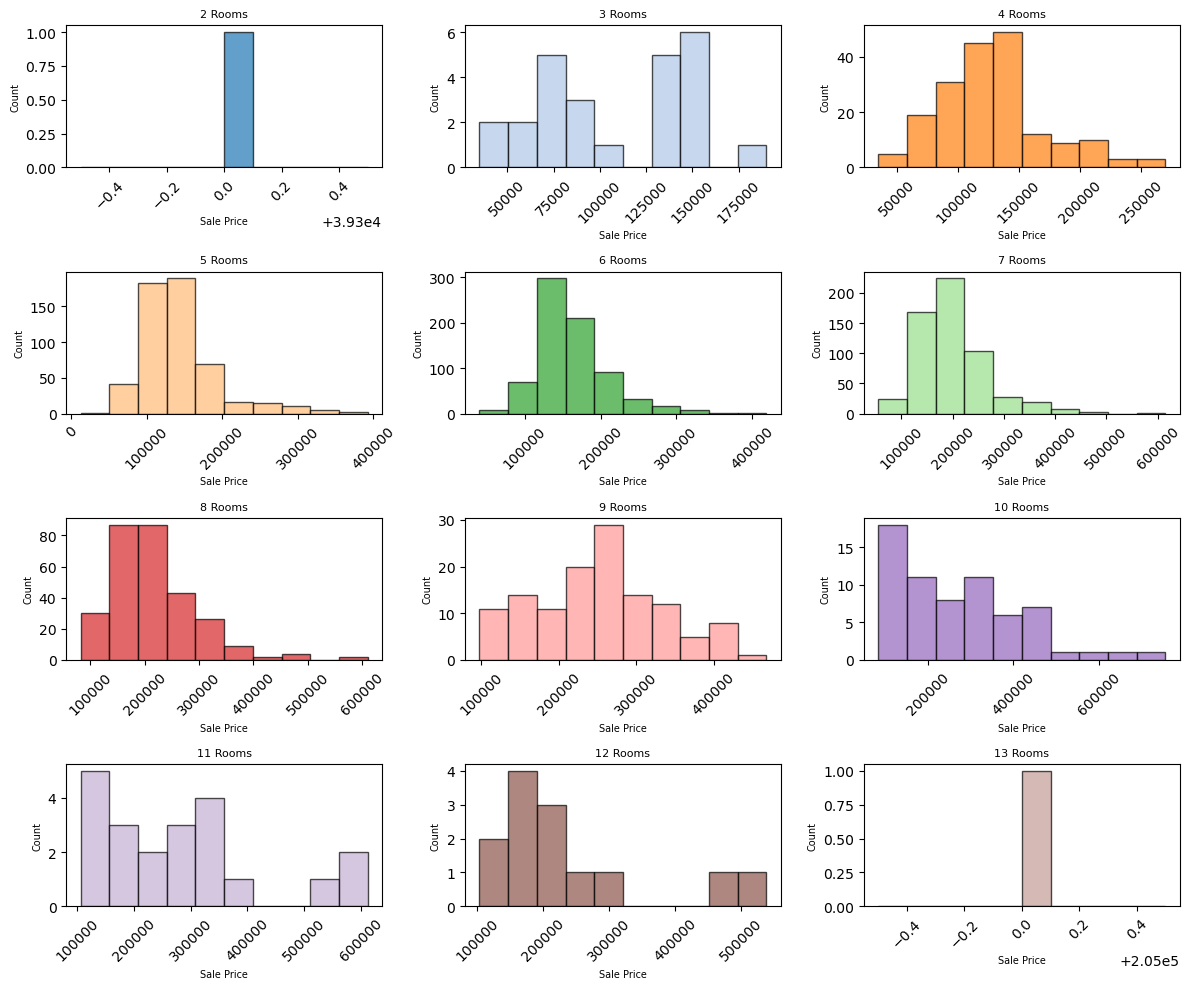

In [28]:
num_rooms = sorted(price['TotRmsAbvGrd'].dropna().unique())

num_histograms = len(num_rooms)
num_rows = 4
num_cols = 3

# Create a figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 10))

# Flatten the axes array to iterate through subplots easily
axes_flat = axes.flatten()

# Get a list of (12) distinct colors from the tab20 colormap
colors = plt.cm.tab20.colors[:num_histograms]

# Iterate through the DataFrame columns and plot histograms with distinct colors
for i, (room_count, ax) in enumerate(zip(num_rooms, axes_flat)):
    subset = price[price['TotRmsAbvGrd'] == room_count]
    ax.hist(subset['SalePrice'], bins=10, alpha=0.7, color=colors[i], edgecolor='black')
    ax.set_title(f'{int(room_count)} Rooms', fontsize=8)
    ax.set_xlabel('Sale Price', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(axis='x', labelrotation=45)

# Remove any extra empty subplots if the number of variables is less than 16
if i < len(axes_flat) - 1:
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

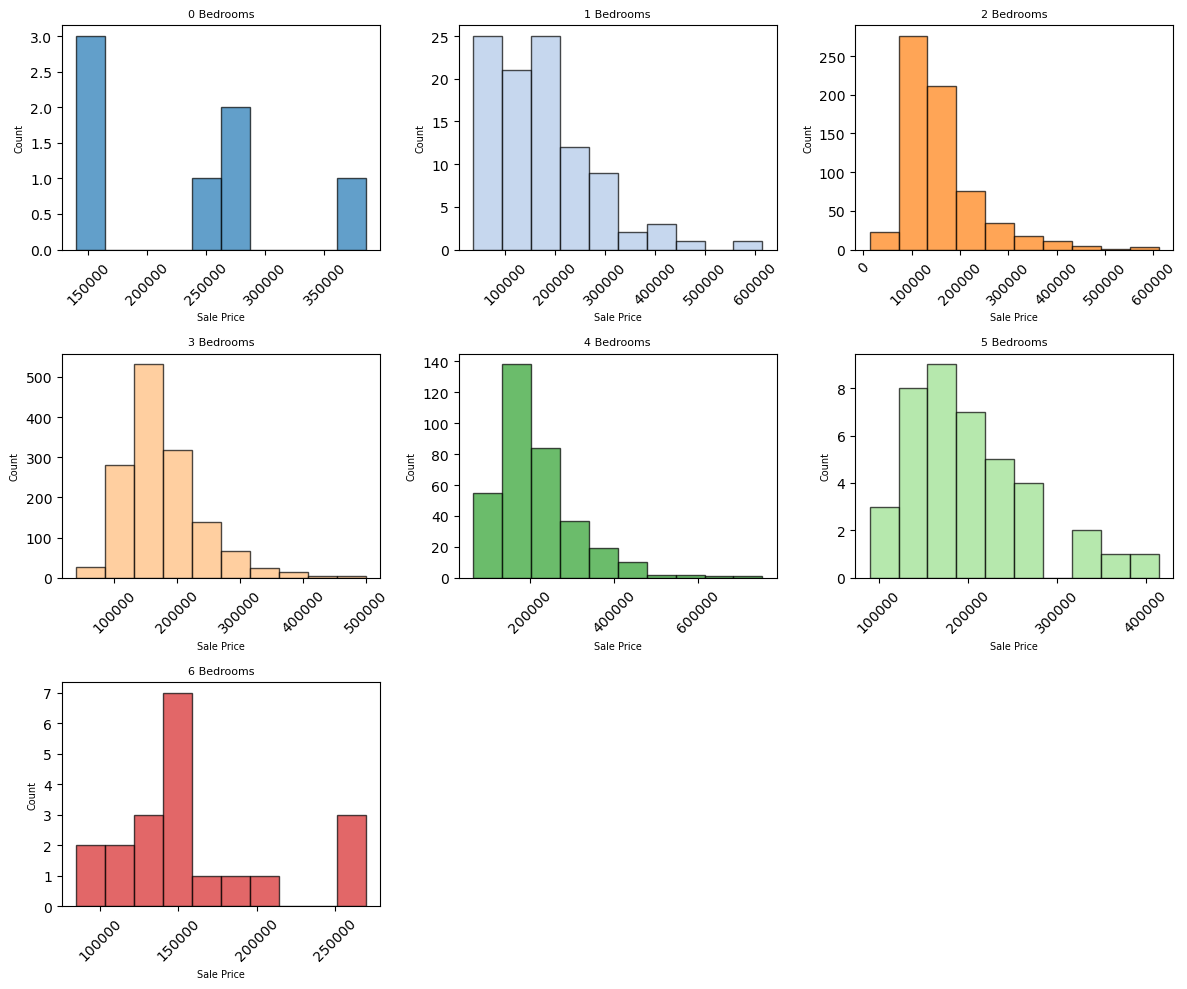

In [29]:
num_bedrooms = sorted(price['BedroomAbvGr'].dropna().unique())

num_histograms = len(num_bedrooms)
num_rows = 3
num_cols = 3

# Create a figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 10))

# Flatten the axes array to iterate through subplots easily
axes_flat = axes.flatten()

# Get a list of (12) distinct colors from the tab20 colormap
colors = plt.cm.tab20.colors[:num_histograms]

# Iterate through the DataFrame columns and plot histograms with distinct colors
for i, (bedroom_count, ax) in enumerate(zip(num_bedrooms, axes_flat)):
    subset = price[price['BedroomAbvGr'] == bedroom_count]
    ax.hist(subset['SalePrice'], bins=10, alpha=0.7, color=colors[i], edgecolor='black')
    ax.set_title(f'{int(bedroom_count)} Bedrooms', fontsize=8)
    ax.set_xlabel('Sale Price', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(axis='x', labelrotation=45)

# Remove any extra empty subplots if the number of variables is less than 16
if i < len(axes_flat) - 1:
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

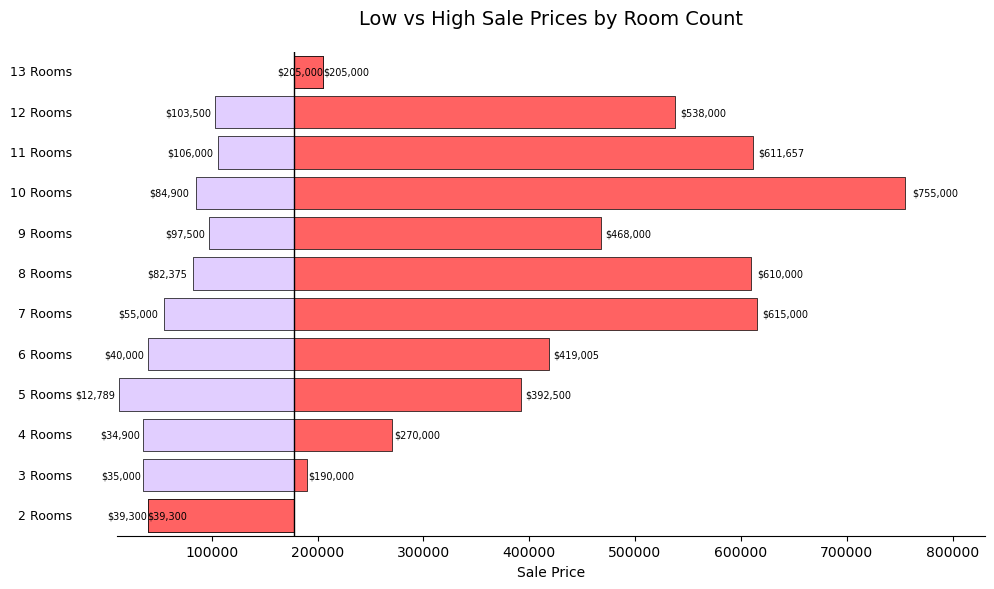

In [30]:
price_range = price.groupby('TotRmsAbvGrd')['SalePrice'].agg(['min', 'max']).reset_index()
labels = price_range['TotRmsAbvGrd'].astype(str).values
low_values = price_range['min'].values
high_values = price_range['max'].values
midpoint = price['SalePrice'].mean()  # or set a custom midpoint

# Now, define the tornado_chart function
def tornado_chart(labels, midpoint, low_values, high_values, title="Low vs High Sale Prices"):
    color_low = '#e1ceff'
    color_high = '#ff6262'
    
    ys = range(len(labels))  # Correct to use input labels length

    fig, ax = plt.subplots(figsize=(10, 6))
    
    for y, low_value, high_value in zip(ys, low_values, high_values):
        low_width = midpoint - low_value
        high_width = high_value - midpoint

        ax.broken_barh(
            [
                (low_value, low_width),
                (midpoint, high_width)
            ],
            (y-0.4, 0.8),
            facecolors=[color_low, color_high],
            edgecolors=['black', 'black'],
            linewidth=0.5
        )
        
        offset = (high_value - low_value) * 0.01
        
        ax.text(low_value - offset, y, f"${low_value:,.0f}", va='center', ha='right', fontsize=7)
        ax.text(high_value + offset, y, f"${high_value:,.0f}", va='center', ha='left', fontsize=7)

        ax.text(low_values.min() * -2.5, y, f"{labels[y]} Rooms", va='center', ha='right', fontsize=9)
    
    ax.axvline(midpoint, color='black', linewidth=1)

    ax = plt.gca()
    ax.spines[['right', 'left', 'top']].set_visible(False)
    ax.set_yticks([])
    
    ax.set_xlabel('Sale Price')
    ax.set_xlim(low_values.min() * 0.8, high_values.max() * 1.1)
    ax.set_ylim(-0.5, len(labels) - 0.5)
    ax.tick_params(left=False)
    
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# Finally, call it
tornado_chart(labels, midpoint, low_values, high_values, title="Low vs High Sale Prices by Room Count")

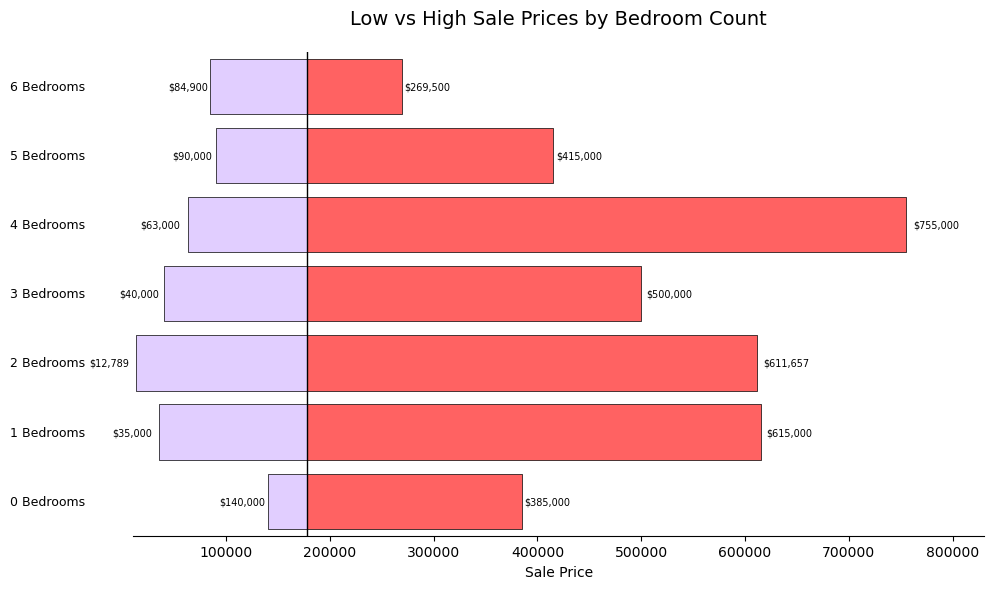

In [31]:
price_range = price.groupby('BedroomAbvGr')['SalePrice'].agg(['min', 'max']).reset_index()
labels = price_range['BedroomAbvGr'].astype(str).values
low_values = price_range['min'].values
high_values = price_range['max'].values
midpoint = price['SalePrice'].mean()  # or set a custom midpoint

# Now, define the tornado_chart function
def tornado_chart(labels, midpoint, low_values, high_values, title="Low vs High Sale Prices"):
    color_low = '#e1ceff'
    color_high = '#ff6262'
    
    ys = range(len(labels))  # Correct to use input labels length
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for y, low_value, high_value in zip(ys, low_values, high_values):
        low_width = midpoint - low_value
        high_width = high_value - midpoint

        ax.broken_barh(
            [
                (low_value, low_width),
                (midpoint, high_width)
            ],
            (y-0.4, 0.8),
            facecolors=[color_low, color_high],
            edgecolors=['black', 'black'],
            linewidth=0.5
        )
        
        offset = (high_value - low_value) * 0.01
        
        ax.text(low_value - offset, y, f"${low_value:,.0f}", va='center', ha='right', fontsize=7)
        ax.text(high_value + offset, y, f"${high_value:,.0f}", va='center', ha='left', fontsize=7)

        ax.text(low_values.min() * -2.8, y, f"{labels[y]} Bedrooms", va='center', ha='right', fontsize=9)
    
    ax.axvline(midpoint, color='black', linewidth=1)

    ax = plt.gca()
    ax.spines[['right', 'left', 'top']].set_visible(False)
    ax.set_yticks([])
    
    ax.set_xlabel('Sale Price')
    ax.set_xlim(low_values.min() * 0.8, high_values.max() * 1.1)
    ax.set_ylim(-0.5, len(labels) - 0.5)
    ax.tick_params(left=False)
    
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# Finally, call it
tornado_chart(labels, midpoint, low_values, high_values, title="Low vs High Sale Prices by Bedroom Count")

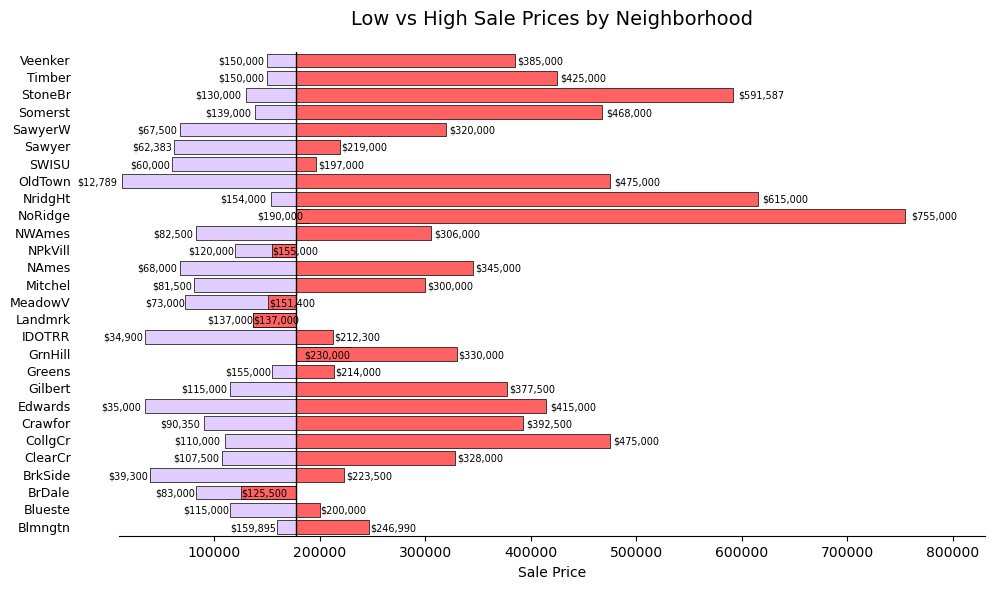

In [32]:
price_range = price.groupby('Neighborhood')['SalePrice'].agg(['min', 'max']).reset_index()
labels = price_range['Neighborhood'].astype(str).values
low_values = price_range['min'].values
high_values = price_range['max'].values
midpoint = price['SalePrice'].mean()  # or set a custom midpoint

# Now, define the tornado_chart function
def tornado_chart(labels, midpoint, low_values, high_values, title="Low vs High Sale Prices"):
    color_low = '#e1ceff'
    color_high = '#ff6262'
    
    ys = range(len(labels))  # Correct to use input labels length
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for y, low_value, high_value in zip(ys, low_values, high_values):
        low_width = midpoint - low_value
        high_width = high_value - midpoint

        ax.broken_barh(
            [
                (low_value, low_width),
                (midpoint, high_width)
            ],
            (y-0.4, 0.8),
            facecolors=[color_low, color_high],
            edgecolors=['black', 'black'],
            linewidth=0.5
        )
        
        offset = (high_value - low_value) * 0.01
        
        ax.text(low_value - offset, y, f"${low_value:,.0f}", va='center', ha='right', fontsize=7)
        ax.text(high_value + offset, y, f"${high_value:,.0f}", va='center', ha='left', fontsize=7)

        ax.text(low_values.min() * -2.8, y, f"{labels[y]}", va='center', ha='right', fontsize=9)
    
    ax.axvline(midpoint, color='black', linewidth=1)

    ax = plt.gca()
    ax.spines[['right', 'left', 'top']].set_visible(False)
    ax.set_yticks([])
    
    ax.set_xlabel('Sale Price')
    ax.set_xlim(low_values.min() * 0.8, high_values.max() * 1.1)
    ax.set_ylim(-0.5, len(labels) - 0.5)
    ax.tick_params(left=False)
    
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# Finally, call it
tornado_chart(labels, midpoint, low_values, high_values, title="Low vs High Sale Prices by Neighborhood")

<BarContainer object of 7 artists>

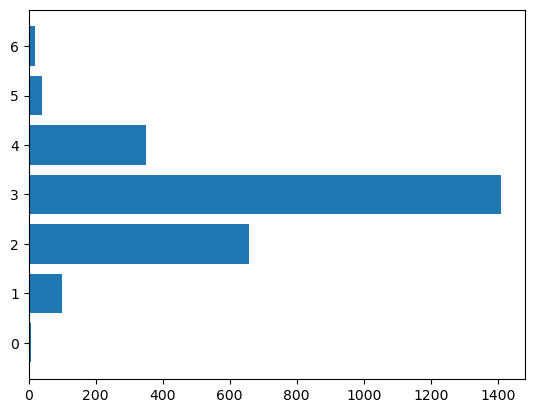

In [33]:
plt.barh(y = price['BedroomAbvGr'].value_counts().index, width = price['BedroomAbvGr'].value_counts().values)

<BarContainer object of 12 artists>

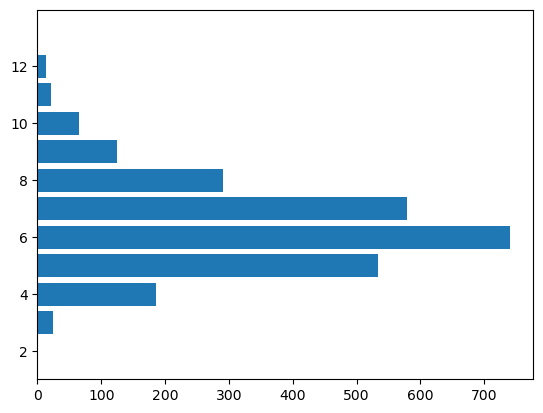

In [34]:
plt.barh(y = price['TotRmsAbvGrd'].value_counts().index, width = price['TotRmsAbvGrd'].value_counts().values)

In [95]:
avg_price_by_neighborhood = price.groupby('Neighborhood')['SalePrice'].mean().reset_index()
avg_price_by_neighborhood.head(2)

,Neighborhood,SalePrice
0,Blmngtn,196237.173913
1,Blueste,143590.000000


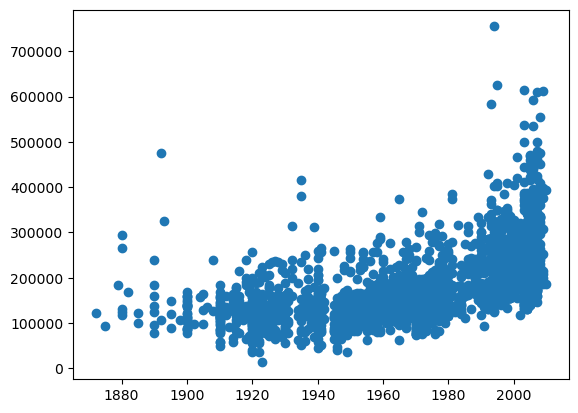

In [36]:
plt.scatter(x = price['YearBuilt'], y = price['SalePrice'])

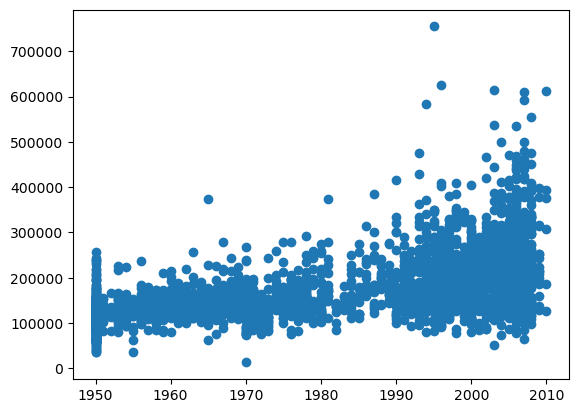

In [37]:
plt.scatter(x = price['YearRemodAdd'], y = price['SalePrice'])

Text(0.5, 0, 'Above Ground Living Area')

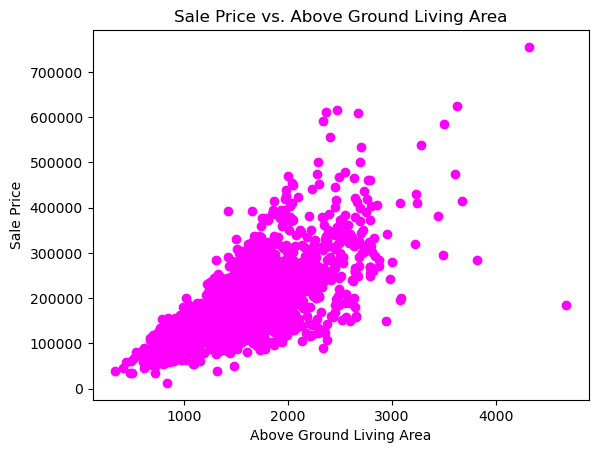

In [38]:
plt.scatter(x = price['GrLivArea'], y = price['SalePrice'], color = 'magenta')
plt.title('Sale Price vs. Above Ground Living Area')
plt.ylabel('Sale Price')
plt.xlabel('Above Ground Living Area')

Text(0.5, 0, 'Total Area')

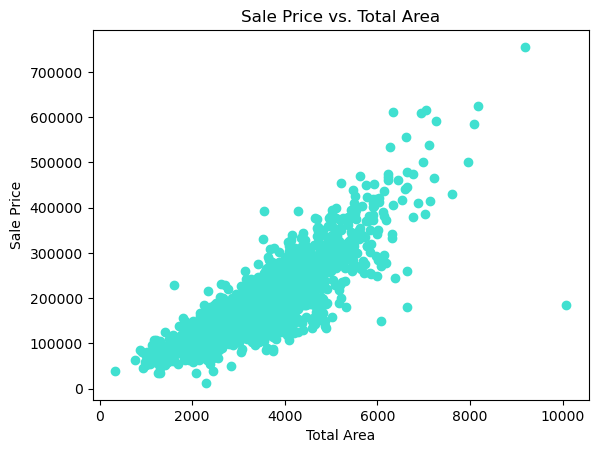

In [39]:
plt.scatter(x = price['TotalArea'], y = price['SalePrice'], color = 'turquoise')
plt.title('Sale Price vs. Total Area')
plt.ylabel('Sale Price')
plt.xlabel('Total Area')

/var/folders/cl/t0tgh5md7pj6srx85p45398h0000gq/T/ipykernel_15446/323523287.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Neighborhood', x='SalePrice', data=df, palette = palette, order=neighborhood_order)


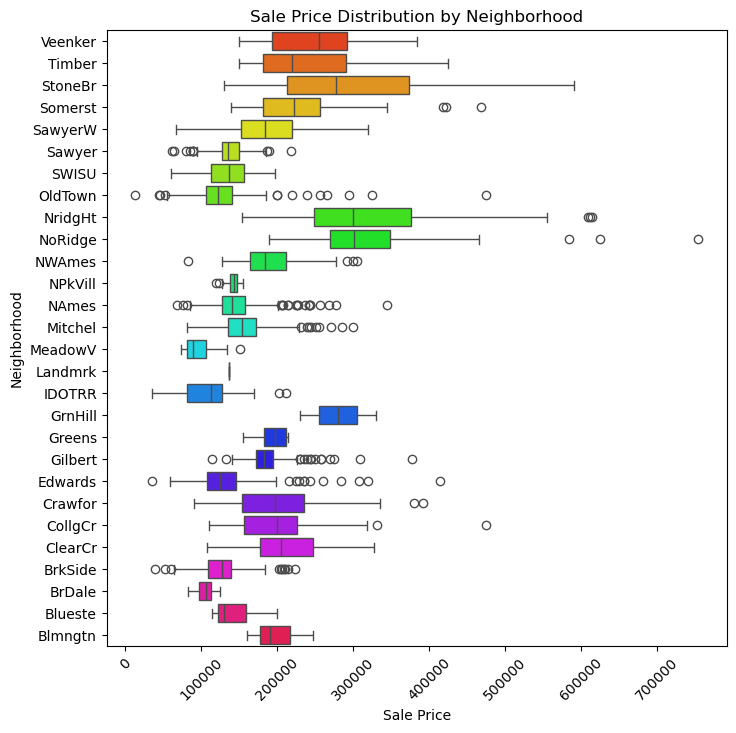

In [40]:
# Prepare data
df = price[['Neighborhood', 'SalePrice']].dropna()

neighborhood_order = sorted(df['Neighborhood'].unique(), reverse=True)

palette = sns.color_palette("hsv", len(neighborhood_order))

# Plot boxplots
plt.figure(figsize=(8, 8))
sns.boxplot(y='Neighborhood', x='SalePrice', data=df, palette = palette, order=neighborhood_order)
plt.title('Sale Price Distribution by Neighborhood')
plt.ylabel('Neighborhood')
plt.xlabel('Sale Price')
plt.xticks(rotation=45)  # Rotate x-labels if they overlap
plt.show()


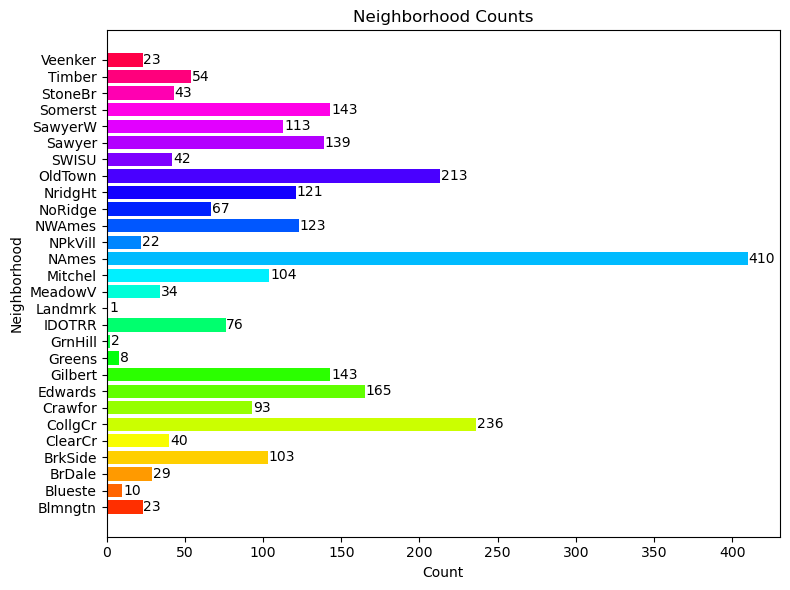

In [41]:
# Get neighborhood order
neighborhood_order = sorted(df['Neighborhood'].unique(), reverse=False)

# Get counts in the correct order
neighborhood_counts = df['Neighborhood'].value_counts()
neighborhood_counts = neighborhood_counts.reindex(neighborhood_order)

# Generate color palette
palette = sns.color_palette("hsv", len(neighborhood_order))

# Plot horizontal bar chart
plt.figure(figsize=(8,6))
bars = plt.barh(y=neighborhood_counts.index, width=neighborhood_counts.values, color=palette)
plt.xlabel('Count')
plt.ylabel('Neighborhood')
plt.title('Neighborhood Counts')

# Add numbers on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             str(int(width)), va='center')

plt.tight_layout()
plt.show()